# Long-term Structural Comparison (2003 vs 2024)
## 日本梨生産構造の長期比較（2003年・2024年）

## Chapter Objective/本章の目的

This chapter examines long-term changes in Japanese pear production
by comparing production structures in 2003 and 2024.
Building on the cross-sectional analysis in the previous chapter,
the focus here is placed on identifying structural shifts over time,
rather than short-term yield fluctuations or annual trends.

By comparing cultivated area and yield per unit area across two points in time,
this chapter aims to clarify how regional production structures
have evolved over the past two decades.

本章では、2003年と2024年のデータを比較することで、
日本梨の生産構造が長期的にどのように変化してきたのかを分析します。
前章で行った横断的な構造分析を踏まえ、
本章では短期的な変動ではなく、
20年間にわたる構造的な変化に着目します。

結果樹面積と10a当たり収量という二つの指標を用い、
産地ごとの生産構造がどのように推移してきたのかを整理します。

## Data Preparation (2003 & 2024)/データ前処理（2003年・2024年）

This section prepares prefecture-level production data for long-term comparison.
Statistics from 2003 and 2024 are aligned in structure and variable definitions
to enable a consistent comparison of production scale and efficiency
across two points in time.

本節では、2003年および2024年の都道府県別統計データを整理し、
長期比較が可能な形式に整えます。
指標の定義と構造を揃えることで、
生産規模と効率の変化を一貫した基準で比較します。

In [ ]:
import pandas as pd

df_2003 = pd.read_excel("japanese_pear_2003.xlsx")
df_2024 = pd.read_excel("japanese_pear_2024.xlsx")

# Quick inspection
print("2003 data shape:", df_2003.shape)
print("2024 data shape:", df_2024.shape)

df_2003.head(), df_2024.head()

2003 data shape: (30, 4)
2024 data shape: (30, 4)


(  prefecture  結果樹面積  10a当たり収量    収穫量
 0         宮城    188      1980   3730
 1         秋田    247      1760   4340
 2         山形    131      1440   1880
 3         福島   1160      2210  25700
 4         茨城   1600      2130  34000,
   prefecture  結果樹面積  10a当たり収量    収穫量
 0         宮城    129      1710   2210
 1         秋田    154      1490   2290
 2         山形     99      1380   1370
 3         福島    751      1970  14800
 4         茨城    815      2100  17100)

In [ ]:
df_2003 = df_2003.copy()
df_2024 = df_2024.copy()

df_2003["year"] = 2003
df_2024["year"] = 2024

In [ ]:
df_merge_check = df_2003.merge(
    df_2024,
    on="prefecture",
    how="outer",
    indicator=True,
    suffixes=("_2003", "_2024")
)

df_merge_check["_merge"].value_counts()

,count
_merge,
both,29
left_only,1
right_only,1


In [ ]:
df_merge_check[df_merge_check["_merge"] != "both"][["prefecture", "_merge"]]

,prefecture,_merge
8,山口,right_only
27,長崎,left_only


The merge result indicates that a small number of prefectures
do not have one-to-one correspondence between 2003 and 2024.
To ensure consistency in long-term structural comparison,
subsequent analysis focuses on prefectures
with confirmed data in both years.

結合処理の結果、一部の都道府県について
2003年と2024年の一対一対応が取れないことが確認されました。
長期的な構造比較の一貫性を確保するため、
以降の分析では両年においてデータが確認できる
都道府県のみを対象としています。

In [ ]:
df_merge_valid = df_merge_check[df_merge_check["_merge"] == "both"].copy()

In [ ]:
df_merge_valid["prefecture"].nunique()

29

In [ ]:
df_merge_valid = df_merge_check[df_merge_check["_merge"] == "both"].copy()

In [ ]:
df_merge_valid.to_excel(
    "japanese_pear_structural_comparison_2003_2024.xlsx",
    index=False
)

In [ ]:
df_merge_valid["prefecture"].is_unique

True

In [ ]:
df = pd.read_excel("japanese_pear_structural_comparison_2003_2024.xlsx")

df.head()

,prefecture,結果樹面積_2003,10a当たり収量_2003,収穫量_2003,year_2003,結果樹面積_2024,10a当たり収量_2024,収穫量_2024,year_2024,_merge
0,京都,101,2030,2050,2003,54,1410,761,2024,both
1,佐賀,413,1930,7950,2003,152,1890,2870,2024,both
2,兵庫,109,1980,2160,2003,61,1540,939,2024,both
3,千葉,1660,1970,32800,2003,1250,1710,21400,2024,both
4,埼玉,678,2360,16000,2003,310,1830,5670,2024,both


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   prefecture     29 non-null     object
 1   結果樹面積_2003     29 non-null     int64 
 2   10a当たり収量_2003  29 non-null     int64 
 3   収穫量_2003       29 non-null     int64 
 4   year_2003      29 non-null     int64 
 5   結果樹面積_2024     29 non-null     int64 
 6   10a当たり収量_2024  29 non-null     int64 
 7   収穫量_2024       29 non-null     int64 
 8   year_2024      29 non-null     int64 
 9   _merge         29 non-null     object
dtypes: int64(8), object(2)
memory usage: 2.4+ KB


前処理の結果に基づき、 長期比較が可能な都道府県のみを抽出し、 分析用の整理済みデータセットを作成した。

Based on the preprocessing results, only the prefectures for which long-term comparisons are possible were extracted, and a cleaned dataset for analysis was created.


## National-level Structural Change/全国レベルにおける生産構造の変化

This section compares national-level averages in 2003 and 2024
to illustrate long-term structural changes in Japanese pear production.
  
本節では、2003年と2024年の全国平均値を比較し、
日本梨生産における長期的な構造変化を確認します。


In [ ]:
national_avg = pd.DataFrame({
    "year": [2003, 2024],
    "area": [
        df["結果樹面積_2003"].mean(),
        df["結果樹面積_2024"].mean()
    ],
    "yield": [
        df["10a当たり収量_2003"].mean(),
        df["10a当たり収量_2024"].mean()
    ]
})

national_avg

,year,area,yield
0,2003,481.551724,2126.551724
1,2024,294.000000,1681.758621


In [ ]:
national_avg["area_change_pct"] = None
national_avg["yield_change_pct"] = None

national_avg.loc[national_avg["year"] == 2024, "area_change_pct"] = (
    (national_avg.loc[national_avg["year"] == 2024, "area"].values[0]
     - national_avg.loc[national_avg["year"] == 2003, "area"].values[0])
    / national_avg.loc[national_avg["year"] == 2003, "area"].values[0]
    * 100
)

national_avg.loc[national_avg["year"] == 2024, "yield_change_pct"] = (
    (national_avg.loc[national_avg["year"] == 2024, "yield"].values[0]
     - national_avg.loc[national_avg["year"] == 2003, "yield"].values[0])
    / national_avg.loc[national_avg["year"] == 2003, "yield"].values[0]
    * 100
)

national_avg

,year,area,yield,area_change_pct,yield_change_pct
0,2003,481.551724,2126.551724,None,None
1,2024,294.000000,1681.758621,-38.947368,-20.916167


Percentage changes are shown for 2024 relative to the 2003 baseline.

変化率は2003年を基準として2024年時点で算出している。

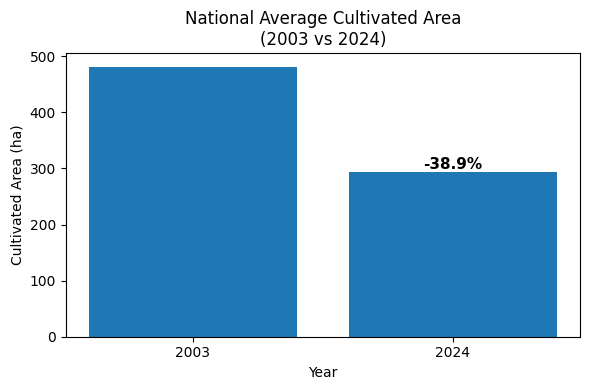

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    national_avg["year"].astype(str),
    national_avg["area"]
)

plt.text(
    x=1,
    y=national_avg.loc[1, "area"],
    s=f"{national_avg.loc[1, 'area_change_pct']:.1f}%",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

plt.title("National Average Cultivated Area\n(2003 vs 2024)")
plt.ylabel("Cultivated Area (ha)")
plt.xlabel("Year")

plt.tight_layout()
plt.show()

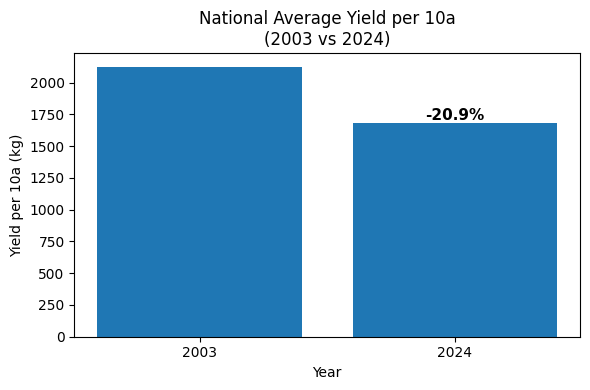

In [ ]:
plt.figure(figsize=(6,4))

plt.bar(
    national_avg["year"].astype(str),
    national_avg["yield"]
)

plt.text(
    x=1,
    y=national_avg.loc[1, "yield"],
    s=f"{national_avg.loc[1, 'yield_change_pct']:.1f}%",
    ha="center",
    va="bottom",
    fontsize=11,
    fontweight="bold"
)

plt.title("National Average Yield per 10a\n(2003 vs 2024)")
plt.ylabel("Yield per 10a (kg)")
plt.xlabel("Year")

plt.tight_layout()
plt.show()

Over the past 20 years, cultivated area has declined by approximately 38.5%, while yield per 10a has decreased by about 20.5%.

This asymmetric change indicates that the long-term structural transformation of Japanese pear production has been driven primarily by a contraction in production scale rather than a proportional decline in productivity.

The figure below illustrates this structural shift in the area–yield space, visually confirming that the reduction in cultivated area is substantially larger than the decline in yield.

この20年間で、結果樹面積は約38.5%減少した一方、10a当たり収量の減少幅は約20.5%にとどまっている。

この非対称的な変化から、日本梨生産の長期的な構造変化は、生産効率の低下よりも、生産規模の縮小によって主導されていると解釈できる。

下図はこの構造変化を結果樹面積と単位収量の関係上で示したものであり、単位収量と比較して結果樹面積の縮小が大きいことを視覚的に確認できる。


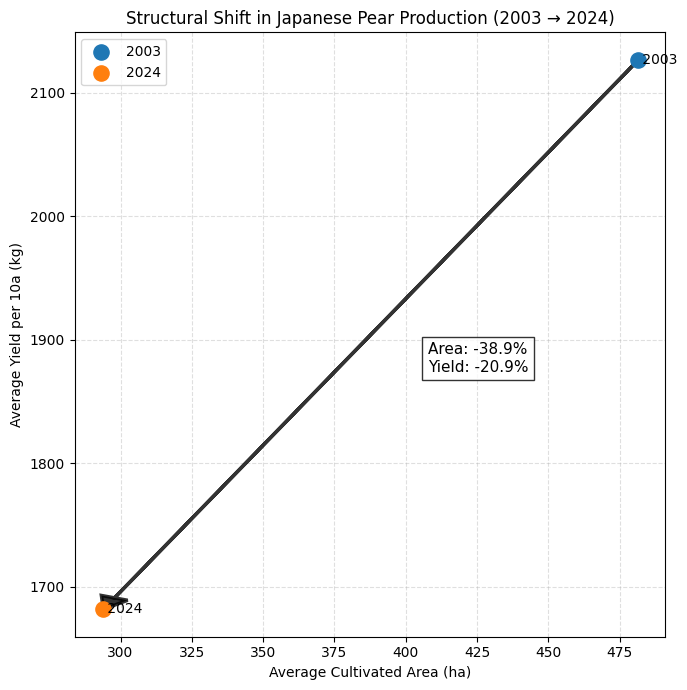

In [ ]:
import matplotlib.pyplot as plt

area_2003 = national_avg.loc[national_avg["year"] == 2003, "area"].values[0]
yield_2003 = national_avg.loc[national_avg["year"] == 2003, "yield"].values[0]

area_2024 = national_avg.loc[national_avg["year"] == 2024, "area"].values[0]
yield_2024 = national_avg.loc[national_avg["year"] == 2024, "yield"].values[0]

area_pct = (area_2024 - area_2003) / area_2003 * 100
yield_pct = (yield_2024 - yield_2003) / yield_2003 * 100

plt.figure(figsize=(7,7))

plt.scatter(area_2003, yield_2003, s=120, label="2003", zorder=3)
plt.scatter(area_2024, yield_2024, s=120, label="2024", zorder=3)

plt.arrow(
    area_2003,
    yield_2003,
    area_2024 - area_2003,
    yield_2024 - yield_2003,
    length_includes_head=True,
    head_width=10,
    head_length=10,
    linewidth=2.5,
    alpha=0.8,
    fc="black",
    ec="black",
    zorder=2
)

plt.text(area_2003, yield_2003, " 2003", va="center", fontsize=10)
plt.text(area_2024, yield_2024, " 2024", va="center", fontsize=10)

mid_x = (area_2003 + area_2024) / 2 + 20
mid_y = (yield_2003 + yield_2024) / 2 - 30

plt.text(
    mid_x,
    mid_y,
    f"Area: {area_pct:.1f}%\nYield: {yield_pct:.1f}%",
    fontsize=11,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.xlabel("Average Cultivated Area (ha)")
plt.ylabel("Average Yield per 10a (kg)")
plt.title("Structural Shift in Japanese Pear Production (2003 → 2024)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()

plt.show()

## Prefecture-level Structural Shifts/都道府県別にみる生産構造の移動

While the previous section examined national-level structural change,
this section focuses on how individual prefectures
have shifted within the production structure over time.
By comparing the relative positions of prefectures in 2003 and 2024,
it becomes possible to observe heterogeneous structural trajectories
across regions.

前節では全国平均の構造的な移動を確認しましたが、
本節では都道府県ごとに、
生産構造がどのように変化してきたのかを分析します。
2003年と2024年の位置関係を比較することで、
産地ごとの異なる構造的な推移を把握します。

To quantify structural contraction in the two-dimensional space,
changes in cultivated area and yield per 10a were combined
using the Euclidean distance:

$$
\text{Structural Shift Magnitude}
= \sqrt{(\Delta \text{Area})^2 + (\Delta \text{Yield})^2}
$$

where  
$\Delta \text{Area}$ represents the change in cultivated area between 2003 and 2024,  
and  
$\Delta \text{Yield}$ represents the change in yield per 10a over the same period.

二次元空間における生産構造の変化量を定量化するため、
結果樹面積と10a当たり収量の変化を
ユークリッド距離として統合した。

$$
\text{構造移動量}
= \sqrt{(\Delta \text{結果樹面積})^2 + (\Delta \text{10a当たり収量})^2}
$$

ここで、  
$\Delta \text{結果樹面積}$ は2003年から2024年にかけた面積の変化量、  
$\Delta \text{10a当たり収量}$ は同期間における単位収量の変化量を表す。

This metric captures the magnitude of structural change by integrating shifts in both cultivated area and yield.

As the objective of this analysis is to interpret structural changes within the original production space, no standardization is applied.

本指標は、結果樹面積と単位収量の両方向の変化を統合することで、構造変化の大きさを捉えている。

また、本分析では構造変化を元の生産構造空間において解釈することを重視しているため、標準化は行っていない。


In [ ]:
import numpy as np

df["area_change"] = (
    df["結果樹面積_2024"] - df["結果樹面積_2003"]
)

df["yield_change"] = (
    df["10a当たり収量_2024"] - df["10a当たり収量_2003"]
)

df["structural_shift_magnitude"] = np.sqrt(
    df["area_change"]**2 +
    df["yield_change"]**2
)

In [ ]:
df[[
    "prefecture",
    "area_change",
    "yield_change",
    "structural_shift_magnitude"
]].head()

,prefecture,area_change,yield_change,structural_shift_magnitude
0,京都,-47,-620,621.778900
1,佐賀,-261,-40,264.047344
2,兵庫,-48,-440,442.610438
3,千葉,-410,-260,485.489444
4,埼玉,-368,-530,645.231741


In [ ]:
df.sort_values(
    "structural_shift_magnitude",
    ascending=False
).head(10)

,prefecture,結果樹面積_2003,10a当たり収量_2003,収穫量_2003,year_2003,結果樹面積_2024,10a当たり収量_2024,収穫量_2024,year_2024,_merge,area_change,yield_change,structural_shift_magnitude
13,新潟,546,3150,17200,2003,357,1630,5820,2024,both,-189,-1520,1531.705259
18,石川,160,2780,4440,2003,129,1620,2090,2024,both,-31,-1160,1160.414150
20,福井,76,2050,1560,2003,61,1150,702,2024,both,-15,-900,900.124991
28,鳥取,1390,2200,30600,2003,538,1910,10300,2024,both,-852,-290,900.002222
11,徳島,263,2470,6510,2003,199,1630,3240,2024,both,-64,-840,842.434567
14,東京,99,2620,2590,2003,67,1810,1210,2024,both,-32,-810,810.631852
25,茨城,1600,2130,34000,2003,815,2100,17100,2024,both,-785,-30,785.573039
12,愛知,421,2230,9370,2003,292,1520,4440,2024,both,-129,-710,721.623863
4,埼玉,678,2360,16000,2003,310,1830,5670,2024,both,-368,-530,645.231741
0,京都,101,2030,2050,2003,54,1410,761,2024,both,-47,-620,621.778900


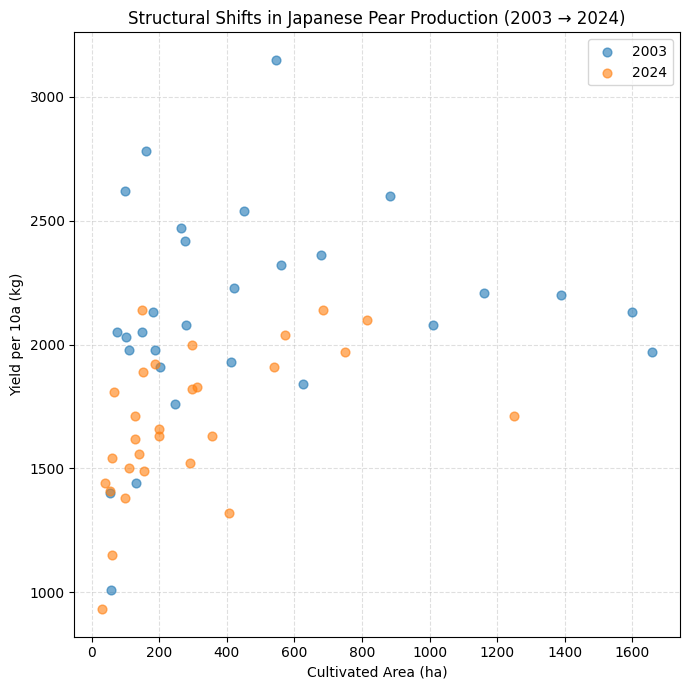

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

plt.scatter(
    df["結果樹面積_2003"],
    df["10a当たり収量_2003"],
    s=40,
    alpha=0.6,
    label="2003",
    zorder=2
)

plt.scatter(
    df["結果樹面積_2024"],
    df["10a当たり収量_2024"],
    s=40,
    alpha=0.6,
    label="2024",
    zorder=3
)

plt.xlabel("Cultivated Area (ha)")
plt.ylabel("Yield per 10a (kg)")
plt.title("Structural Shifts in Japanese Pear Production (2003 → 2024)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


The scatter plot shows the distribution of prefectures
in the area–yield space for 2003 and 2024.
Compared with 2003, the 2024 points are generally shifted
toward lower cultivated area and lower yield per 10a.
This indicates an overall contraction of production structures
in the two-dimensional space, rather than isolated changes
in a small number of prefectures.

本散布図は、2003年および2024年における
都道府県の結果樹面積と10a当たり収量の分布を示している。
2003年と比較すると、2024年の分布は全体として
左下方向にシフトしており、
多くの産地で面積および単位収量の両面が縮小していることが分かる。
これは、一部の都道府県に限られた変化ではなく、
生産構造全体の収縮傾向を反映したものである。

## Final Conclusion/結論
This analysis examined long-term changes in Japanese pear production by focusing on the relationship between cultivated area and yield per 10a.
By comparing data from 2003 and 2024, the results show that production structures have generally shifted toward contraction.

However, this change is not uniform. Different regions show different patterns—for example, some experience a large decline in cultivated area, while others show a more noticeable decrease in yield.

Overall, these results indicate that the long-term change in Japanese pear production is mainly driven by a reduction in production scale.

本分析では、日本梨生産の長期的な変化を、結果樹面積と10a当たり収量の関係から検討した。
2003年と2024年のデータを比較した結果、生産構造は全体として縮小する方向に変化していることが確認された。

この変化は一様ではなく、地域ごとに異なる形で進んでいる。
ある地域では面積の減少が大きく、別の地域では単位収量の低下が目立つなど、それぞれ異なる変化の仕方が見られる。

以上の結果から、日本梨生産の長期的な変化は、生産規模の縮小を中心とした構造的な変化であることが分かる。